<a href="https://colab.research.google.com/github/SiddhidhChChandra/student-placement-prediction/blob/main/student_placement_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Student Placement Prediction using Logistic Regression

## 📌 Objective
This project analyzes student placement data using Exploratory Data Analysis (EDA) and Logistic Regression.

The goal is to understand how CGPA and IQ affect placement probability.

In [116]:
!wget https://raw.githubusercontent.com/campusx-official/placement-project-logistic-regression/main/placement.csv

import pandas as pd

df = pd.read_csv('placement.csv')
df.head()

--2026-05-27 10:58:05--  https://raw.githubusercontent.com/campusx-official/placement-project-logistic-regression/main/placement.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1485 (1.5K) [text/plain]
Saving to: ‘placement.csv.3’

placement.csv.3     100%[===================>]   1.45K  --.-KB/s    in 0s      

2026-05-27 10:58:05 (24.8 MB/s) - ‘placement.csv.3’ saved [1485/1485]



,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


#Dataset Information

The dataset contains:

- CGPA of students
- IQ scores
- Placement status

### Columns:
- `cgpa` → Academic score
- `iq` → IQ level
- `placement` → Placement status (0 = Not Placed, 1 = Placed)

In [117]:
df=df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


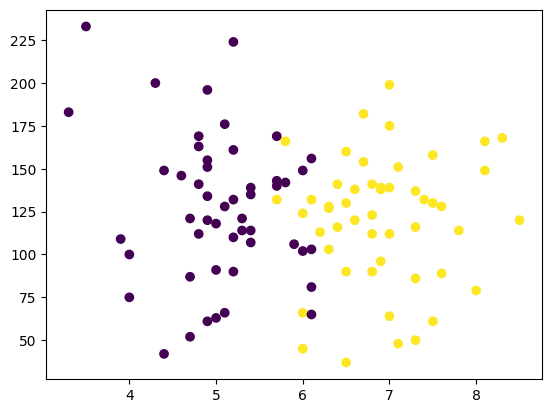

In [118]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [119]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [120]:
x


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [121]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [122]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [123]:
x_test

,cgpa,iq
48,6.6,138.0
62,6.0,102.0
44,7.5,61.0
3,7.4,132.0
68,4.0,75.0
79,6.5,90.0
40,4.9,134.0
0,6.8,123.0
82,6.5,37.0
41,5.4,114.0


In [124]:
from sklearn.preprocessing import StandardScaler


In [125]:
scaler = StandardScaler()

In [126]:
x_train = scaler.fit_transform(x_train)

In [127]:
x_test = scaler.transform(x_test)

In [128]:
from sklearn.linear_model import LogisticRegression

In [129]:
clf=LogisticRegression()

In [130]:
clf.fit(x_train,y_train)

LogisticRegression()

In [131]:
y_pred= clf.predict(x_test)

In [132]:
y_test

,placement
48,1
62,0
44,1
3,1
68,0
79,1
40,0
0,1
82,1
41,0


In [133]:
from sklearn.metrics import accuracy_score

In [134]:
accuracy_score(y_test,y_pred)

0.9

In [135]:
!pip install mlxtend
from mlxtend.plotting import plot_decision_regions

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


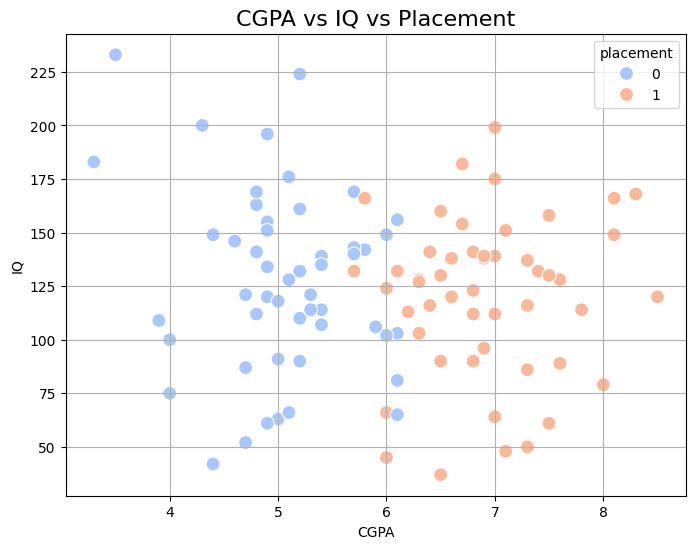

In [137]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='cgpa',y='iq',hue='placement',palette='coolwarm',s=100,data=df)
plt.title("CGPA vs IQ vs Placement", fontsize=16)
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.grid(True)
plt.show()

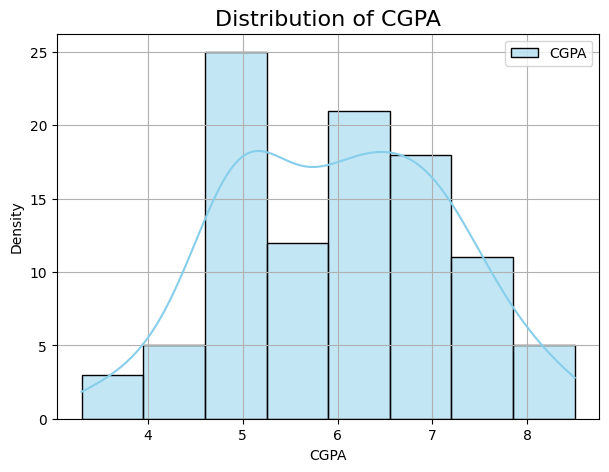

In [138]:
plt.figure(figsize=(7,5))

sns.histplot(df['cgpa'],kde=True,color='skyblue',label='CGPA')
plt.title("Distribution of CGPA", fontsize=16)
plt.xlabel("CGPA")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

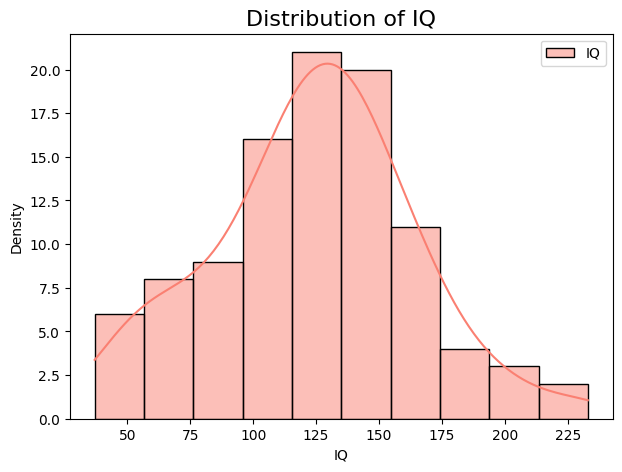

In [139]:
plt.figure(figsize=(7,5))

sns.histplot(df['iq'],kde=True,color='salmon',label='IQ')
plt.title("Distribution of IQ", fontsize=16)
plt.xlabel("IQ")
plt.ylabel("Density")
plt.legend()

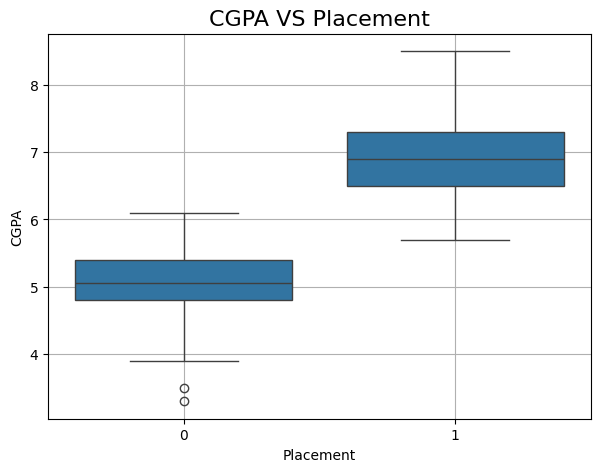

In [140]:
plt.figure(figsize=(7,5))

sns.boxplot(x='placement',y='cgpa', data=df)
plt.title("CGPA VS Placement", fontsize=16)
plt.xlabel("Placement")
plt.ylabel("CGPA")
plt.grid(True)
plt.show()

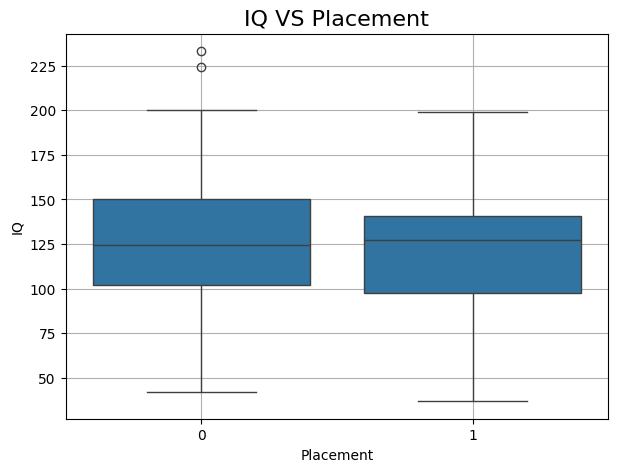

In [141]:
plt.figure(figsize=(7,5))

sns.boxplot(x='placement',y='iq', data=df)
plt.title("IQ VS Placement", fontsize=16)
plt.xlabel("Placement")
plt.ylabel("IQ")
plt.grid(True)

/tmp/ipykernel_7779/697767196.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='placement', data=df, palette='coolwarm')


Text(0, 0.5, 'Count')

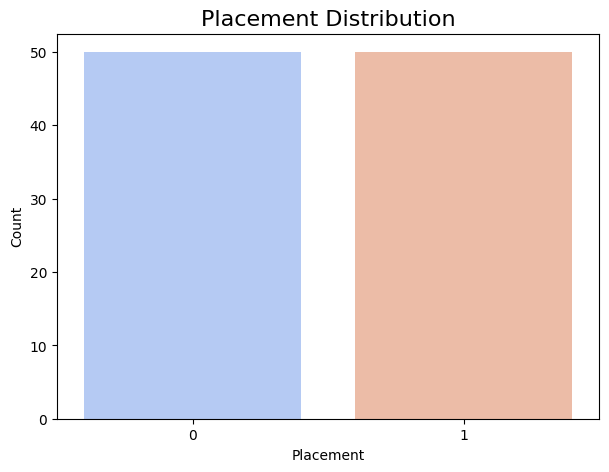

In [142]:
plt.figure(figsize=(7,5))

sns.countplot(x='placement', data=df, palette='coolwarm')
plt.title("Placement Distribution", fontsize=16)
plt.xlabel("Placement")
plt.ylabel("Count")

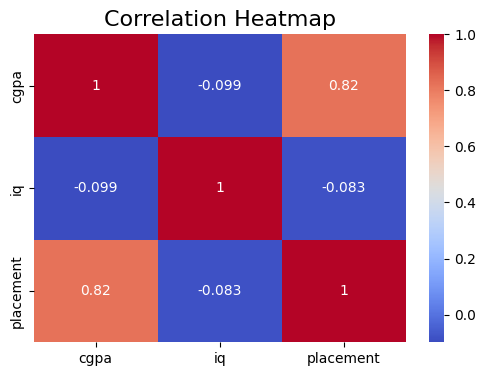

In [143]:
plt.figure(figsize=(6,4))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

# Observations

- Students with higher CGPA tend to have higher placement probability.
- IQ also contributes to placement but appears less influential than CGPA.
- The decision boundary created by Logistic Regression separates placed and non-placed students effectively.
- The model achieved approximately 90% accuracy.

In [144]:
plt.figure(figsize=(8,6))


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

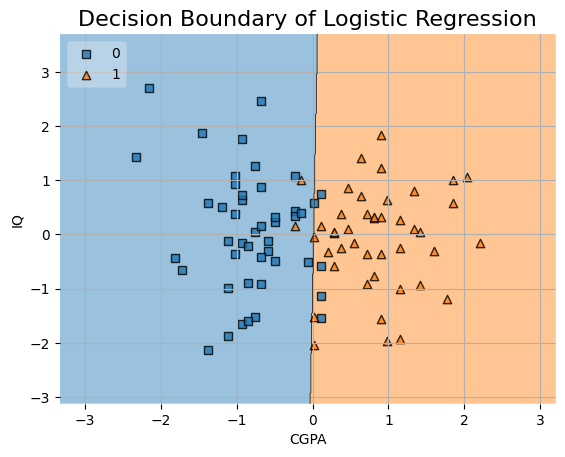

In [145]:
import numpy as np

plot_decision_regions( x_train, np.array(y_train), clf= clf, legend= 2)
plt.title("Decision Boundary of Logistic Regression", fontsize=16)
plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.grid(True)
plt.show()

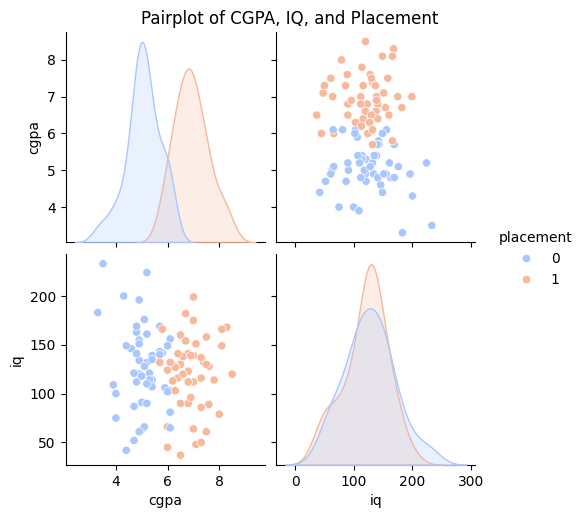

In [146]:
sns.pairplot(df, hue='placement', palette='coolwarm')
plt.suptitle('Pairplot of CGPA, IQ, and Placement', y=1.02)
plt.show()

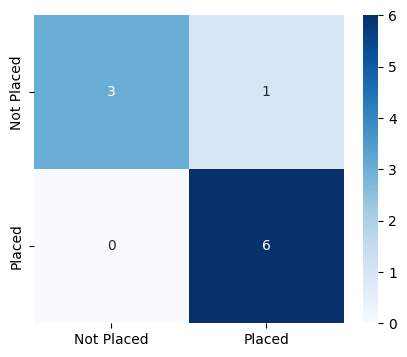

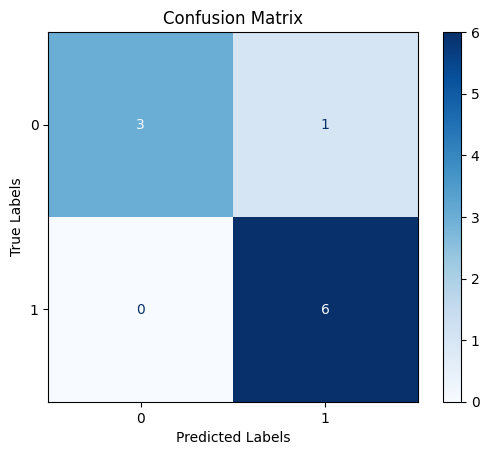

In [147]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [148]:
import pickle

In [149]:
pickle.dump(clf,open('model.pk','wb'))

# Conclusion

This project demonstrates how Logistic Regression can be used to predict student placement based on academic performance and IQ.

Through Exploratory Data Analysis and visualization, we observed strong relationships between CGPA and placement outcomes.

The trained model achieved approximately 90% accuracy on test data.